In [92]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import deque
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [67]:
df_train = pd.read_csv('../data/processed/2017/2017_train_scaled.csv')
df_test = pd.read_csv('../data/processed/2017/2017_test_scaled.csv')

In [68]:
X_train = df_train.drop(columns=["Label"])
X_test = df_test.drop(columns=["Label"])
y_train = df_train['Label']
y_test = df_test['Label']

In [69]:
print(f"X Train shape {X_train.shape}")
print(f"X Test shape {X_test.shape}")
nb_features = len(X_train.columns)

X Train shape (2262300, 49)
X Test shape (565576, 49)


In [70]:
rus = RandomUnderSampler(random_state=42)

X_train, y_train = rus.fit_resample(X_train,y_train)

In [71]:
print(f"X Train shape after undersampling {X_train.shape}")
print(f"X Test shape after undersampling {X_test.shape}")

X Train shape after undersampling (890490, 49)
X Test shape after undersampling (565576, 49)


In [72]:
class DuelingQNetwork(nn.Module):

    def __init__(self,state_size, action_size):

        super(DuelingQNetwork,self).__init__()

        self.net = nn.Sequential(
            nn.Linear(state_size,64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.LayerNorm(32),
            nn.ReLU(),
        )

        self.v = nn.Sequential(
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )

        self.a = nn.Sequential(
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,action_size)
        )

    def forward(self , x):
        x = self.net(x)
        a = self.a(x)
        v = self.v(x)
        return v + (a - a.mean(dim=1, keepdim=True))

In [73]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)  

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)  
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.stack(list(states)).to(device),           
            torch.LongTensor(actions).to(device),
            torch.FloatTensor(rewards).to(device),
            torch.stack(list(next_states)).to(device),       
            torch.FloatTensor(dones).to(device),
        )

    def __len__(self):
        return len(self.buffer)

In [84]:
LEARNING_RATE   = 1e-3
GAMMA           = 0.99
BATCH_SIZE      = 512
WARMUP_STEPS    = 3000
TARGET_UPDATE_FREQ = 1280
EPSILON_START   = 1.0
EPSILON_END     = 0.01
EPISODES    = 20
TRAIN_BATCH_SIZE = 128
TEST_BATCH_SIZE = 4096
TOTAL_STEPS = (len(X_train) // TRAIN_BATCH_SIZE ) * EPISODES
EPSILON_DECAY   = (EPSILON_END / EPSILON_START) ** (1.0 / TOTAL_STEPS)
TAU = 0.005
NB_RUNS = 5

In [85]:
online_net = DuelingQNetwork(nb_features, 2).to(device)
target_net = DuelingQNetwork(nb_features, 2).to(device)
target_net.load_state_dict(online_net.state_dict())
target_net.eval()

memory    = ReplayBuffer(capacity=(100000))
optimizer = optim.Adam(online_net.parameters(), lr=LEARNING_RATE)

In [86]:
def train_step():
    if len(memory) < BATCH_SIZE:
        return None
    states, actions, rewards, next_states, dones = memory.sample(BATCH_SIZE)

    q_values = online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        next_actions = online_net(next_states).argmax(dim=1)
        next_q       = target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze(1)
        target_q     = rewards + GAMMA * next_q * (1 - dones)

    criterion = nn.HuberLoss(delta=1.0)

    loss = criterion(q_values, target_q)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(online_net.parameters(), max_norm=10)
    optimizer.step()

    return loss.item()

In [87]:
X_train_tensor = torch.FloatTensor(X_train.values).to(device)
y_train_tensor = torch.LongTensor(y_train.values).to(device)

In [88]:
total_steps = 0
epsilon = EPSILON_START
epsilon_history = []
episode_rewards = []

for episode in range(1, EPISODES + 1):
    shuffled_idx = np.random.permutation(len(X_train))
    nb_steps = (len(shuffled_idx) // TRAIN_BATCH_SIZE) * TRAIN_BATCH_SIZE
    episode_reward = 0

    print(f"Episode {episode}/{EPISODES} : {nb_steps // TRAIN_BATCH_SIZE} batches")

    for start in range(0, nb_steps - TRAIN_BATCH_SIZE, TRAIN_BATCH_SIZE):
        idx_now  = shuffled_idx[start : start + TRAIN_BATCH_SIZE]
        idx_next = shuffled_idx[start + 1 : start + TRAIN_BATCH_SIZE + 1]

        states     = X_train_tensor[idx_now]       
        true_ys    = y_train_tensor[idx_now]       
        next_states = X_train_tensor[idx_next]      

        if total_steps < WARMUP_STEPS:
            actions = torch.randint(0, 2, (TRAIN_BATCH_SIZE,)).to(device)
        else:
            random_mask = torch.rand(TRAIN_BATCH_SIZE).to(device) < epsilon
            online_net.eval()
            with torch.no_grad():
                greedy_actions = online_net(states).argmax(dim=1)  
            online_net.train()
            random_actions = torch.randint(0, 2, (TRAIN_BATCH_SIZE,)).to(device)
            actions = torch.where(random_mask, random_actions, greedy_actions)

        correct_mask = (actions == true_ys)
        fn_mask      = (actions == 0) & (true_ys == 1) 
        fp_mask      = (actions == 1) & (true_ys == 0) 

        rewards = torch.where(correct_mask, torch.ones(TRAIN_BATCH_SIZE).to(device),
                  torch.where(fn_mask,      torch.full((TRAIN_BATCH_SIZE,), -5.0).to(device),
                                            torch.full((TRAIN_BATCH_SIZE,), -1.0).to(device)))

        dones = torch.zeros(TRAIN_BATCH_SIZE).to(device)
        dones[-1] = 1.0 if start + TRAIN_BATCH_SIZE >= nb_steps - TRAIN_BATCH_SIZE else 0.0

        for i in range(TRAIN_BATCH_SIZE):
            memory.push(states[i], actions[i].item(), rewards[i].item(), next_states[i], dones[i].item())

        episode_reward += rewards.sum().item()
        total_steps    += TRAIN_BATCH_SIZE

        if total_steps >= WARMUP_STEPS and total_steps % TRAIN_BATCH_SIZE == 0:
            train_step()

        if total_steps % TARGET_UPDATE_FREQ == 0:
            for target_param, online_param in zip(target_net.parameters(), online_net.parameters()):
                target_param.data.copy_(TAU * online_param.data + (1 - TAU) * target_param.data)

        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    epsilon_history.append(epsilon)
    episode_rewards.append(episode_reward)
    print(f"Ep {episode:4d} | Reward {episode_reward:7.1f} | Eps {epsilon:.3f}")

torch.save(online_net.state_dict(), "../models/dueling_dqn_2017.pth")

Episode 1/20 : 6956 batches
Ep    1 | Reward -707750.0 | Eps 0.794
Episode 2/20 : 6956 batches
Ep    2 | Reward -390196.0 | Eps 0.631
Episode 3/20 : 6956 batches
Ep    3 | Reward -135940.0 | Eps 0.501
Episode 4/20 : 6956 batches
Ep    4 | Reward 65282.0 | Eps 0.398
Episode 5/20 : 6956 batches
Ep    5 | Reward 225690.0 | Eps 0.316
Episode 6/20 : 6956 batches
Ep    6 | Reward 353350.0 | Eps 0.251
Episode 7/20 : 6956 batches
Ep    7 | Reward 456874.0 | Eps 0.200
Episode 8/20 : 6956 batches
Ep    8 | Reward 537168.0 | Eps 0.159
Episode 9/20 : 6956 batches
Ep    9 | Reward 599582.0 | Eps 0.126
Episode 10/20 : 6956 batches
Ep   10 | Reward 647172.0 | Eps 0.100
Episode 11/20 : 6956 batches
Ep   11 | Reward 691136.0 | Eps 0.079
Episode 12/20 : 6956 batches
Ep   12 | Reward 724324.0 | Eps 0.063
Episode 13/20 : 6956 batches
Ep   13 | Reward 748128.0 | Eps 0.050
Episode 14/20 : 6956 batches
Ep   14 | Reward 770060.0 | Eps 0.040
Episode 15/20 : 6956 batches
Ep   15 | Reward 787618.0 | Eps 0.032
Ep

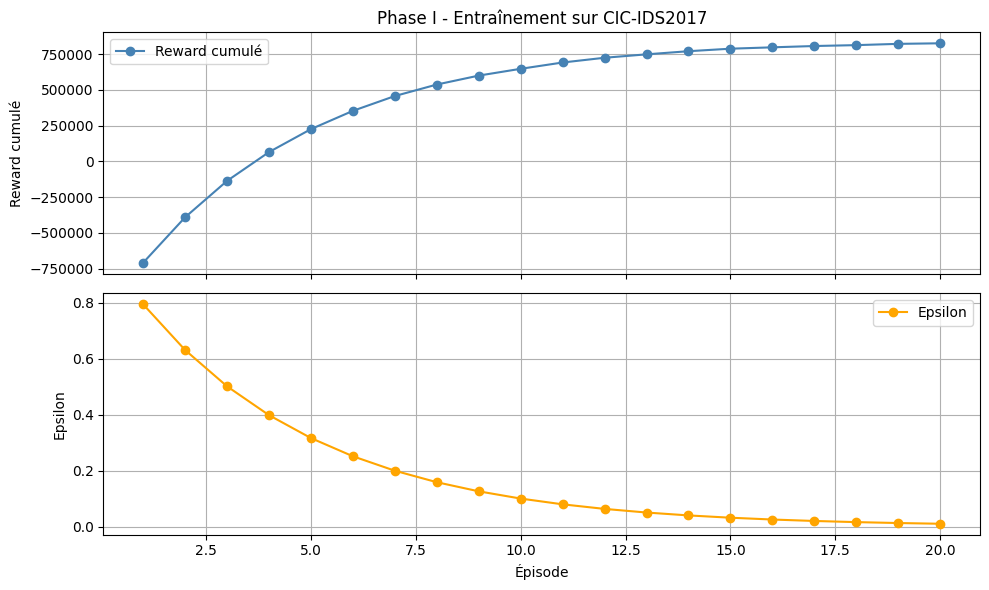

In [89]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(range(1, EPISODES + 1), episode_rewards, marker='o', color='steelblue', label='Reward cumulé')
ax1.set_ylabel("Reward cumulé")
ax1.set_title("Phase I - Entraînement sur CIC-IDS2017")
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, EPISODES + 1), epsilon_history, marker='o', color='orange', label='Epsilon')
ax2.set_ylabel("Epsilon")
ax2.set_xlabel("Épisode")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("../figures/training_phase1.png", dpi=150)
plt.show()

In [94]:
online_net.load_state_dict(torch.load("../models/dueling_dqn_2017.pth"))
online_net.eval()

y_pred = []
with torch.no_grad():
    for i in range(0, len(X_test), TEST_BATCH_SIZE):
        batch = torch.FloatTensor(X_test[i:i+TEST_BATCH_SIZE].values).to(device)
        q_values = online_net(batch)
        preds = q_values.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)

  
y_pred = np.array(y_pred)  

print(f"Classification Report  : \n{classification_report(y_test, y_pred)}")

Classification Report  : 
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    454265
           1       0.91      1.00      0.95    111311

    accuracy                           0.98    565576
   macro avg       0.96      0.99      0.97    565576
weighted avg       0.98      0.98      0.98    565576



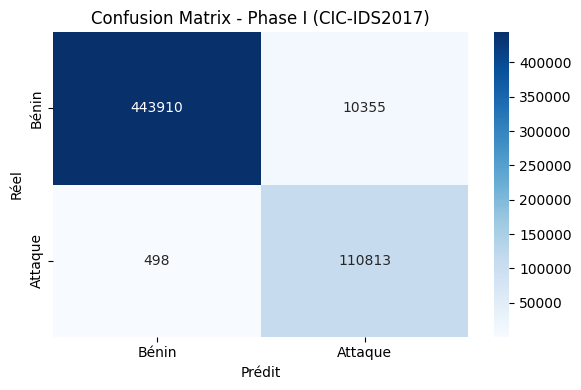

In [95]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bénin', 'Attaque'],
            yticklabels=['Bénin', 'Attaque'])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Confusion Matrix - Phase I (CIC-IDS2017)")
plt.tight_layout()
plt.savefig("../figures/confusion_matrix_phase1.png", dpi=150)
plt.show()